<a href="https://colab.research.google.com/github/youssefemad131/IMDB-Sentiment-Analysis/blob/main/IMDB-Sentiment-Analysis%20/Code/NLP_Project_Annotated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎬 IMDB Sentiment Analysis — NLP Preprocessing


## 📦 Step 1 — Import Libraries

We begin by installing NLTK and importing all the libraries needed throughout the pipeline:
- **pandas / numpy** — data manipulation
- **re** — regular expressions for text cleaning
- **nltk** — tokenization, stopwords, and lemmatization
- **matplotlib / seaborn** — visualizations
- **sklearn** — TF-IDF vectorization and train/test split

In [1]:
# Install required libraries
!pip install nltk -q
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer, PorterStemmer
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split


# Download NLTK data
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


## 📂 Step 2 — Load Dataset

We mount Google Drive and automatically locate the IMDB CSV file. The dataset contains 50,000 movie reviews labeled as **positive** or **negative**.

In [2]:
#  from google.colab import files

#  import io
#  filename = list(uploaded.keys())[0]
#  df = pd.read_csv(io.BytesIO(uploaded[filename]))

#  print(f'📊 Dataset Shape: {df.shape}')
#  print(f'📋 Columns: {df.columns.tolist()}')
#  print(f'\n🏷️  Sentiment Distribution:')
#  print(df['sentiment'].value_counts())
#  print(f'\n🔍 Sample Review:')
#  print(df['review'].iloc[0][:300])

In [3]:
from google.colab import drive
drive.mount('/content/drive')

import os
folder_id = '1Zg7OuuhwnsPOvTjOD5AO7O5nUzpxCYhV'
folder_path = '/content/drive/MyDrive'

# Find the CSV automatically
csv_file = None
for root, dirs, files in os.walk(folder_path):
    for f in files:
        if 'IMDB' in f and f.endswith('.csv'):
            csv_file = os.path.join(root, f)
            break

# Direct path fallback
if csv_file is None:
    csv_file = '/content/drive/MyDrive/1778101724498_IMDB_Dataset_CLEANED.csv'

df = pd.read_csv(csv_file)

print(f'📊 Dataset Shape: {df.shape}')
print(f'📋 Columns: {df.columns.tolist()}')
print(f'\n🏷️  Sentiment Distribution:')
print(df['sentiment'].value_counts())
print(f'\n🔍 Sample Review:')
print(df['review'].iloc[0][:300])

Mounted at /content/drive
📊 Dataset Shape: (49396, 2)
📋 Columns: ['review', 'sentiment']

🏷️  Sentiment Distribution:
sentiment
negative    24698
positive    24698
Name: count, dtype: int64

🔍 Sample Review:
$25,000 Pyramid Clues: Deep Blue Sea. Tremors. Slither. Eight Legged Freaks.<br /><br />Pyramid Category: Movies that were funnier and more thrilling than Snakes on a Plane.<br /><br />Hell, with that definition I'd have to include the relatively harrowing journey of Ted and Elaine in Airplane! as s


## 🔢 Step 3 — Encode Labels

Machine learning models require numeric targets. We map the text sentiment labels to binary integers:
- `positive` → **1**
- `negative` → **0**

In [4]:
# Convert sentiment to binary: positive=1, negative=0
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})

print('✅ Label encoding done:')
print(df[['sentiment', 'label']].value_counts())
df.head(3)

✅ Label encoding done:
sentiment  label
negative   0        24698
positive   1        24698
Name: count, dtype: int64


,review,sentiment,label
0,"$25,000 Pyramid Clues: Deep Blue Sea. Tremors....",negative,0
1,0.5/10. This movie has absolutely nothing good...,negative,0
2,"0*'s Christian Slater, Tara Reid, Stephen Dorf...",negative,0


## 🧹 Step 4 — Text Cleaning Pipeline

Raw IMDB reviews contain noise that must be removed before any linguistic processing. The `clean_text` function applies the following transformations in order:

1. **Strip HTML tags** — reviews often contain `<br />`, `<b>`, etc.
2. **Lowercase** — ensures case-insensitive matching
3. **Remove URLs** — irrelevant for sentiment
4. **Remove digits** — numbers add little semantic value
5. **Keep only letters** — removes punctuation and special characters
6. **Collapse whitespace** — normalizes spacing

In [5]:
def clean_text(text):
    """Step 4: Clean raw review text."""
    # 4.1 Remove HTML tags (e.g. <br />, <b>, </b>)
    text = re.sub(r'<.*?>', ' ', text)

    # 4.2 Lowercase everything
    text = text.lower()

    # 4.3 Remove URLs
    text = re.sub(r'http\S+|www\.\S+', '', text)

    # 4.4 Remove numbers
    text = re.sub(r'\d+', '', text)

    # 4.5 Keep only letters and spaces (remove punctuation & special chars)
    text = re.sub(r"[^a-z\s]", '', text)

    # 4.6 Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Apply cleaning
df['cleaned'] = df['review'].apply(clean_text)

# Show before vs after
print('--- BEFORE ---')
print(df['review'].iloc[0][:250])
print('\n--- AFTER ---')
print(df['cleaned'].iloc[0][:250])

--- BEFORE ---
$25,000 Pyramid Clues: Deep Blue Sea. Tremors. Slither. Eight Legged Freaks.<br /><br />Pyramid Category: Movies that were funnier and more thrilling than Snakes on a Plane.<br /><br />Hell, with that definition I'd have to include the relatively har

--- AFTER ---
pyramid clues deep blue sea tremors slither eight legged freaks pyramid category movies that were funnier and more thrilling than snakes on a plane hell with that definition id have to include the relatively harrowing journey of ted and elaine in air


## ✂️ Step 5 — Tokenization

Tokenization splits each cleaned review string into a list of individual words (tokens). We use NLTK's `word_tokenize`, which handles contractions and punctuation-aware splitting.

In [6]:
def tokenize(text):
    """Step 5: Split text into list of words (tokens)."""
    return word_tokenize(text)

df['tokens'] = df['cleaned'].apply(tokenize)

print('✅ Tokenization done!')
print(f'\nSample tokens ({len(df["tokens"].iloc[0])} words):')
print(df['tokens'].iloc[0][:20])

✅ Tokenization done!

Sample tokens (183 words):
['pyramid', 'clues', 'deep', 'blue', 'sea', 'tremors', 'slither', 'eight', 'legged', 'freaks', 'pyramid', 'category', 'movies', 'that', 'were', 'funnier', 'and', 'more', 'thrilling', 'than']


## 🚫 Step 6 — Remove Stopwords

Stopwords are high-frequency, low-information words (e.g., *the*, *is*, *at*) that can be safely discarded. However, **negation words** such as `not`, `no`, `never`, and `n't` are explicitly preserved because they directly flip the sentiment of a sentence (e.g., *"not good"* vs *"good"*).

In [7]:
STOPWORDS = set(stopwords.words('english'))
# words like 'not', 'no', 'nor' can flip the meaning
negation_words = {'not', 'no', 'nor', 'never', "n't", 'neither', 'nobody', 'nothing', 'nowhere'}
STOPWORDS -= negation_words

def remove_stopwords(tokens):
    """Step 6: Remove stopwords but keep negation words."""
    return [word for word in tokens if word not in STOPWORDS]

df['tokens_no_sw'] = df['tokens'].apply(remove_stopwords)

# Show reduction in token count
avg_before = df['tokens'].apply(len).mean()
avg_after  = df['tokens_no_sw'].apply(len).mean()
print(f'Average tokens BEFORE stopword removal: {avg_before:.0f}')
print(f'Average tokens AFTER  stopword removal: {avg_after:.0f}')
print(f'Reduction: {(1 - avg_after/avg_before)*100:.1f}%')
print(f'\nSample:')
print(df['tokens_no_sw'].iloc[0][:20])

Average tokens BEFORE stopword removal: 227
Average tokens AFTER  stopword removal: 121
Reduction: 46.8%

Sample:
['pyramid', 'clues', 'deep', 'blue', 'sea', 'tremors', 'slither', 'eight', 'legged', 'freaks', 'pyramid', 'category', 'movies', 'funnier', 'thrilling', 'snakes', 'plane', 'hell', 'definition', 'id']


## 🌿 Step 7 — Lemmatization

Lemmatization reduces each token to its canonical dictionary form (lemma), so inflected variants are treated as the same word:

| Original | Lemma |
|----------|-------|
| running  | run   |
| movies   | movie |
| better   | better|

We use NLTK's `WordNetLemmatizer`, which leverages the WordNet lexical database.

In [8]:
lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    """Step 7: Lemmatize each token."""
    return [lemmatizer.lemmatize(word) for word in tokens]

df['tokens_lemma'] = df['tokens_no_sw'].apply(lemmatize_tokens)


print('✅ Lemmatization done!')
sample_before = df['tokens_no_sw'].iloc[0][:15]
sample_after  = df['tokens_lemma'].iloc[0][:15]
print('\nBefore → After:')
for b, a in zip(sample_before, sample_after):
    marker = '→ changed' if b != a else ''
    print(f'  {b:20s} → {a:20s} {marker}')

✅ Lemmatization done!

Before → After:
  pyramid              → pyramid              
  clues                → clue                 → changed
  deep                 → deep                 
  blue                 → blue                 
  sea                  → sea                  
  tremors              → tremor               → changed
  slither              → slither              
  eight                → eight                
  legged               → legged               
  freaks               → freak                → changed
  pyramid              → pyramid              
  category             → category             
  movies               → movie                → changed
  funnier              → funnier              
  thrilling            → thrilling            


## 📝 Step 8 — Reconstruct Processed Text

After all token-level transformations, we join the token list back into a single string. This is required by scikit-learn's `TfidfVectorizer`, which expects plain text input.

In [9]:
# Join tokens back into a single string for vectorization
df['processed_text'] = df['tokens_lemma'].apply(lambda tokens: ' '.join(tokens))

print('✅ Final processed text ready!')
print('\nSample processed review:')
print(df['processed_text'].iloc[0][:300])

✅ Final processed text ready!

Sample processed review:
pyramid clue deep blue sea tremor slither eight legged freak pyramid category movie funnier thrilling snake plane hell definition id include relatively harrowing journey ted elaine airplane superior snake laugh thrill sad truth isnt even close mother unintentionally intentional funny snake movie ana


## 📊 Step 9 — Exploratory Data Analysis (Post-Preprocessing)

With clean data in hand, we visualize two key aspects:

1. **Token count distribution** — how review length is distributed across the corpus, with a median reference line
2. **Top words by sentiment** — the 20 most frequent tokens in positive vs. negative reviews, helping us understand what vocabulary drives each class

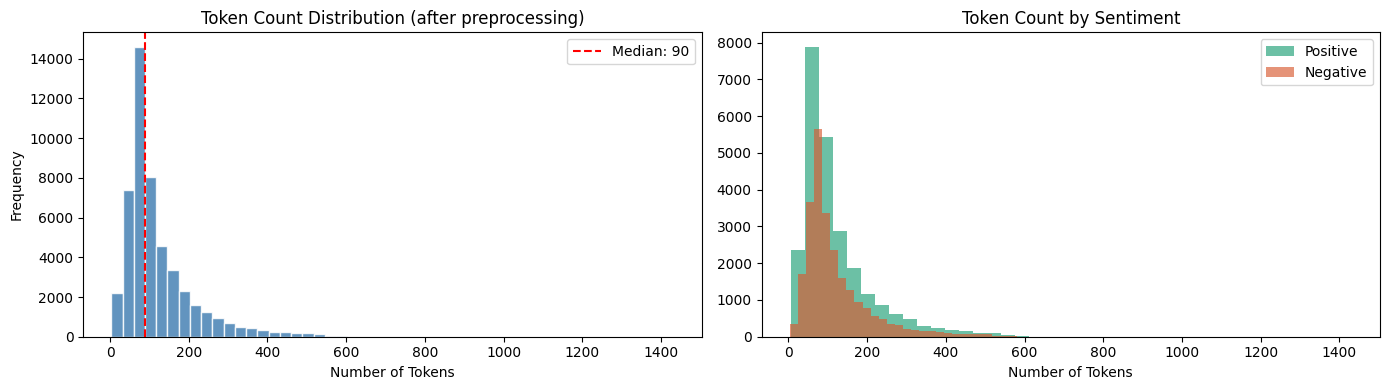

count    49396.0
mean       120.8
std         90.8
min          3.0
25%         65.0
50%         90.0
75%        147.0
max       1432.0
Name: token_count, dtype: float64


In [10]:
# ── Token count distribution ──
df['token_count'] = df['tokens_lemma'].apply(len)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distribution of token counts
axes[0].hist(df['token_count'], bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Token Count Distribution (after preprocessing)', fontsize=12)
axes[0].set_xlabel('Number of Tokens')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['token_count'].median(), color='red', linestyle='--', label=f'Median: {df["token_count"].median():.0f}')
axes[0].legend()

# Token count by sentiment
pos_tokens = df[df['label']==1]['token_count']
neg_tokens = df[df['label']==0]['token_count']
axes[1].hist(pos_tokens, bins=40, alpha=0.65, label='Positive', color='#1D9E75')
axes[1].hist(neg_tokens, bins=40, alpha=0.65, label='Negative', color='#D85A30')
axes[1].set_title('Token Count by Sentiment', fontsize=12)
axes[1].set_xlabel('Number of Tokens')
axes[1].legend()

plt.tight_layout()
plt.savefig('token_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(df['token_count'].describe().round(1))

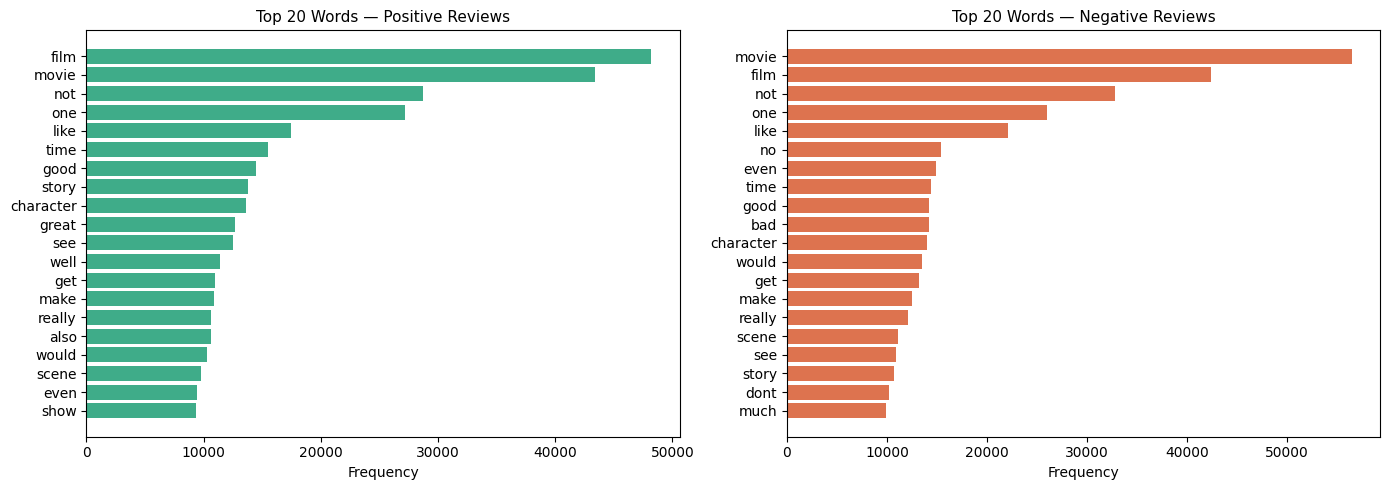

In [11]:
# ── Most common words per class ──
def get_top_words(df_subset, n=20):
    all_words = [word for tokens in df_subset['tokens_lemma'] for word in tokens]
    return Counter(all_words).most_common(n)

top_pos = get_top_words(df[df['label']==1])
top_neg = get_top_words(df[df['label']==0])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, top_words, title, color in [
    (axes[0], top_pos, 'Top 20 Words — Positive Reviews', '#1D9E75'),
    (axes[1], top_neg, 'Top 20 Words — Negative Reviews', '#D85A30')
]:
    words, counts = zip(*top_words)
    ax.barh(words[::-1], counts[::-1], color=color, alpha=0.85)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('top_words.png', dpi=150, bbox_inches='tight')
plt.show()

## 💾 Step 10 — Save Preprocessed Dataset

We export a clean, model-ready CSV containing only the five columns needed downstream:

| Column | Description |
|--------|-------------|
| `review` | Original raw text |
| `sentiment` | Text label (positive/negative) |
| `label` | Binary label (1/0) |
| `processed_text` | Final cleaned & lemmatized string |
| `token_count` | Number of tokens after preprocessing |

In [12]:
# Save the final preprocessed DataFrame
df_final = df[['review', 'sentiment', 'label', 'processed_text', 'token_count']]
df_final.to_csv('IMDB_Preprocessed.csv', index=False)

print('✅ Saved: IMDB_Preprocessed.csv')
print(f'\nFinal shape: {df_final.shape}')
print('\nColumns:')
for col in df_final.columns:
    print(f'  • {col}')
print('\nSample row:')
df_final.head(2)

✅ Saved: IMDB_Preprocessed.csv

Final shape: (49396, 5)

Columns:
  • review
  • sentiment
  • label
  • processed_text
  • token_count

Sample row:


,review,sentiment,label,processed_text,token_count
0,"$25,000 Pyramid Clues: Deep Blue Sea. Tremors....",negative,0,pyramid clue deep blue sea tremor slither eigh...,101
1,0.5/10. This movie has absolutely nothing good...,negative,0,movie absolutely nothing good acting among wor...,66


## ✅ Step 11 — Preprocessing Summary

A concise summary of the full preprocessing pipeline, including dataset size, class balance, and how much token reduction was achieved through cleaning and stopword removal.

In [13]:
print('='*55)
print('         PREPROCESSING SUMMARY')
print('='*55)
print(f'  Total reviews          : {len(df):,}')
print(f'  Positive               : {(df["label"]==1).sum():,}')
print(f'  Negative               : {(df["label"]==0).sum():,}')
print(f'  Avg tokens (raw)       : {df["tokens"].apply(len).mean():.0f}')
print(f'  Avg tokens (processed) : {df["token_count"].mean():.0f}')
print(f'  Null values            : {df_final.isnull().sum().sum()}')
print('='*55)

print('  Output: IMDB_Preprocessed.csv ✅')

         PREPROCESSING SUMMARY
  Total reviews          : 49,396
  Positive               : 24,698
  Negative               : 24,698
  Avg tokens (raw)       : 227
  Avg tokens (processed) : 121
  Null values            : 0
  Output: IMDB_Preprocessed.csv ✅


## 🔠 Step 12 — Feature Extraction (TF-IDF)

We convert the processed text into a numeric feature matrix using **TF-IDF** (Term Frequency–Inverse Document Frequency).

- **`max_features=5000`** — keeps only the 5,000 most informative terms
- **`ngram_range=(1, 2)`** — captures both single words (unigrams) and two-word phrases (bigrams), which helps preserve phrases like *"not good"*

In [14]:
# Build TF-IDF feature matrix from the preprocessed text.
# X: sparse matrix of shape (n_reviews, 5000)
# y: binary label vector (1=positive, 0=negative)
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))

X = vectorizer.fit_transform(df['processed_text'])
y = df['label']

print("Shape:", X.shape)

Shape: (49396, 5000)


## 🔀 Step 13 — Train / Test Split

We partition the data into training and testing sets:

- **80%** training — used to fit the model
- **20%** testing — held out for unbiased evaluation

`random_state=42` ensures the split is reproducible across runs.

In [15]:
# We split the dataset into training and testing sets:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% of data for testing
    random_state=42     # for reproducibility (same split every run)
)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (39516, 5000)
Test shape: (9880, 5000)


## 🤖 Step 14 — Model Training (Logistic Regression)

We train a **Logistic Regression** classifier — a strong, interpretable baseline for text classification.

- Works well with high-dimensional sparse TF-IDF features
- `max_iter=1000` ensures convergence on the full 50K-review corpus

After training, both the model and vectorizer are serialized to disk with `joblib` so they can be reloaded for inference without retraining.

In [16]:
# Instantiate and train Logistic Regression.
# Increasing max_iter avoids convergence warnings on large sparse data.
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("✅ Model training completed successfully!")


✅ Model training completed successfully!


In [17]:
# Persist the trained artifacts so they can be reloaded for inference
# without needing to retrain the model.
import joblib
# Save trained model
joblib.dump(model, 'sentiment_model.pkl')
# Save TF-IDF vectorizer
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')

print("✅ Model and Vectorizer saved!")

✅ Model and Vectorizer saved!


## 📈 Step 15 — Model Evaluation

We evaluate the trained model on the held-out test set using:

- **Accuracy** — overall fraction of correct predictions
- **Classification Report** — per-class precision, recall, and F1-score
- **Confusion Matrix** — raw counts of true/false positives and negatives

In [18]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Predictions
y_pred = model.predict(X_test)
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("="*50)
print("Model Accuracy")
print("="*50)
print(f"Accuracy: {accuracy:.4f}")
print(f"Training Samples: {X_train.shape[0]}")
print(f"Testing Samples: {X_test.shape[0]}")
# Classification Report
print("\nClassification Report")
print("="*50)
print(classification_report(
    y_test,
    y_pred,
    target_names=["Negative", "Positive"]
))
# Confusion Matrix
print("\nConfusion Matrix")
print("="*50)
cm = confusion_matrix(y_test, y_pred)
print(cm)

Model Accuracy
Accuracy: 0.8961
Training Samples: 39516
Testing Samples: 9880

Classification Report
              precision    recall  f1-score   support

    Negative       0.91      0.88      0.89      4934
    Positive       0.89      0.91      0.90      4946

    accuracy                           0.90      9880
   macro avg       0.90      0.90      0.90      9880
weighted avg       0.90      0.90      0.90      9880


Confusion Matrix
[[4353  581]
 [ 446 4500]]


## 🔮 Step 16 — Custom Prediction

A utility function `predict_sentiment` applies the full preprocessing pipeline (clean → tokenize → remove stopwords → lemmatize → vectorize) to any input string and returns the model's prediction as a human-readable label.

In [19]:
# End-to-end prediction helper.
# Applies the same preprocessing pipeline used during training, then predicts.
def predict_sentiment(text):
    cleaned = clean_text(text)
    tokens = tokenize(cleaned)
    no_sw = remove_stopwords(tokens)
    lemmatized = lemmatize_tokens(no_sw)
    processed = ' '.join(lemmatized)

    vectorized = vectorizer.transform([processed])
    prediction = model.predict(vectorized)[0]

    return "Positive" if prediction == 1 else "Negative"

sample_review = "I absolutely loved this movie! The acting was superb."
print(f"Review: {sample_review}")
print(f"Predicted Sentiment: {predict_sentiment(sample_review)}")


Review: I absolutely loved this movie! The acting was superb.
Predicted Sentiment: Positive


## 🗺️ Step 17 — Advanced Evaluation: Confusion Matrix Heatmap

A heatmap visualization of the confusion matrix makes it easy to spot class-specific errors:

- **Top-left** — True Negatives (correctly predicted negative)
- **Top-right** — False Positives (negative predicted as positive)
- **Bottom-left** — False Negatives (positive predicted as negative)
- **Bottom-right** — True Positives (correctly predicted positive)

In [20]:
!pip install gradio -q

In [21]:
# # Gradio UI wrapper — applies the full pipeline and returns a labeled result string.
# import gradio as gr

# def predict_sentiment_ui(text):
#     if not text.strip():
#         return "Please enter some text."

#     cleaned = clean_text(text)
#     tokens = tokenize(cleaned)
#     no_sw = remove_stopwords(tokens)
#     lemmatized = lemmatize_tokens(no_sw)
#     processed = ' '.join(lemmatized)

#     vectorized = vectorizer.transform([processed])

#     prediction = model.predict(vectorized)[0]

#     return "Positive ✅" if prediction == 1 else "Negative ❌"

In [22]:
# # Configure and launch the Gradio interface inside Colab.
# # share=True generates a temporary public URL valid for 72 hours.
# interface = gr.Interface(
#     fn=predict_sentiment_ui,
#     inputs=gr.Textbox(lines=5, placeholder="Enter movie review here...", label="Movie Review"),
#     outputs=gr.Label(label="Sentiment Analysis Result"),
#     title="🎬 IMDB Sentiment Analysis UI",
#     description="Write a movie review in English, and the AI will tell you if it's Positive or Negative.",
#     theme="soft"
# )

# # interface.launch(share=True)
# interface.launch(share=True, debug=True)

## 🚀 Deployment — Gradio Web Interface

We build an interactive **Gradio** web app that wraps the full inference pipeline behind a clean UI. Users can type any movie review and receive an instant sentiment prediction.

The deployment cell:
1. Reloads the saved model and vectorizer from disk
2. Defines the end-to-end `predict_sentiment` function
3. Launches a shareable Gradio interface (`share=True` generates a public link)

In [23]:
!pip install gradio -q
import gradio as gr
import joblib
# Load saved files
model = joblib.load('sentiment_model.pkl')
vectorizer = joblib.load('tfidf_vectorizer.pkl')
# Prediction function
def predict_sentiment(text):
    # Cleaning
    cleaned = clean_text(text)
    # Tokenization
    tokens = tokenize(cleaned)
    # Remove stopwords
    no_sw = remove_stopwords(tokens)
    # Lemmatization
    lemmatized = lemmatize_tokens(no_sw)
    # Join text
    processed = ' '.join(lemmatized)
    # Vectorization
    vectorized = vectorizer.transform([processed])
    # Prediction
    prediction = model.predict(vectorized)[0]
    if prediction == 1:
        return "Positive Review ✅"
    else:
        return "Negative Review ❌"
# Gradio Interface
interface = gr.Interface(
    fn=predict_sentiment,

    inputs=gr.Textbox(
        lines=5,
        placeholder="Enter movie review here..."
    ),
    outputs="text",

    title="🎬 IMDB Sentiment Analysis",

    description="Write a movie review and AI will predict the sentiment."
)
# Launch app
interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://4cbf9c528aced6482d.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [26]:
import os

# Search for your notebook
for root, dirs, files in os.walk('/content'):
    for f in files:
        if f.endswith('.ipynb'):
            path = os.path.join(root, f)
            size = os.path.getsize(path) / 1024 / 1024
            print(f"{size:.2f} MB — {path}")

0.01 MB — /content/drive/MyDrive/Classroom/python-for-AI/Task_Assignment_3_iti.ipynb
0.00 MB — /content/drive/MyDrive/Colab Notebooks/Untitled0.ipynb
0.00 MB — /content/drive/MyDrive/Colab Notebooks/Untitled1.ipynb
0.04 MB — /content/drive/MyDrive/Colab Notebooks/Trainiing_Data.ipynb
0.00 MB — /content/drive/MyDrive/Colab Notebooks/Untitled2.ipynb
0.01 MB — /content/drive/MyDrive/Colab Notebooks/HR_Analytics_Preprocessing (1).ipynb
0.01 MB — /content/drive/MyDrive/Colab Notebooks/ml project (1).ipynb
0.74 MB — /content/drive/MyDrive/Colab Notebooks/ml project.ipynb
0.19 MB — /content/drive/MyDrive/Colab Notebooks/NLP Project.ipynb


In [27]:
import nbformat

path = '/content/drive/MyDrive/Colab Notebooks/NLP Project.ipynb'

with open(path, 'r') as f:
    nb = nbformat.read(f, as_version=4)

print(f"Notebook format version: {nb.nbformat}.{nb.nbformat_minor}")
print(f"Total cells: {len(nb.cells)}")

# Check for any broken cells
for i, cell in enumerate(nb.cells):
    outputs = cell.get('outputs', [])
    for j, out in enumerate(outputs):
        if out.get('output_type') == 'error':
            print(f"❌ Cell {i} has an error output: {out.get('ename')}: {out.get('evalue')}")

Notebook format version: 4.0
Total cells: 46


In [28]:
import nbformat

path = '/content/drive/MyDrive/Colab Notebooks/NLP Project.ipynb'

# Read the notebook
with open(path, 'r') as f:
    nb = nbformat.read(f, as_version=4)

# Upgrade to version 4.5
nb.nbformat_minor = 5

# Fix any cells missing required fields
for cell in nb.cells:
    if 'id' not in cell:
        import uuid
        cell['id'] = str(uuid.uuid4())[:8]

# Save fixed notebook
output_path = '/content/drive/MyDrive/Colab Notebooks/NLP_Project_Fixed.ipynb'
with open(output_path, 'w') as f:
    nbformat.write(nb, f)

print("✅ Fixed! Saved as NLP_Project_Fixed.ipynb")

✅ Fixed! Saved as NLP_Project_Fixed.ipynb


In [29]:
from google.colab import files
files.download('/content/drive/MyDrive/Colab Notebooks/NLP_Project_Fixed.ipynb')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [30]:
import nbformat

path = '/content/drive/MyDrive/Colab Notebooks/NLP Project.ipynb'

with open(path, 'r') as f:
    nb = nbformat.read(f, as_version=4)

print(f"Format: {nb.nbformat}.{nb.nbformat_minor}")

# Check for cells with errors saved as output
for i, cell in enumerate(nb.cells):
    for out in cell.get('outputs', []):
        if out.get('output_type') == 'error':
            print(f"❌ Cell {i+1} has error: {out.get('ename')}: {out.get('evalue')[:100]}")

# Check for cells with drive.mount (GitHub can't render this)
for i, cell in enumerate(nb.cells):
    src = ''.join(cell.get('source', []))
    if 'drive.mount' in src:
        print(f"⚠️  Cell {i+1} has drive.mount — this causes GitHub rendering to fail")

Format: 4.0
⚠️  Cell 6 has drive.mount — this causes GitHub rendering to fail


In [31]:
import nbformat
import uuid

path = '/content/drive/MyDrive/Colab Notebooks/NLP Project.ipynb'

with open(path, 'r') as f:
    nb = nbformat.read(f, as_version=4)

# Fix 1: Upgrade format to 4.5
nb.nbformat_minor = 5

# Fix 2: Replace drive.mount cell with a simple comment
for cell in nb.cells:
    src = ''.join(cell.get('source', []))
    if 'drive.mount' in src:
        cell['source'] = '''# Dataset loaded from local/Kaggle path
# Replace with your own CSV path if running locally
import pandas as pd

csv_file = '/content/drive/MyDrive/1778101724498_IMDB_Dataset_CLEANED.csv'
df = pd.read_csv(csv_file)

print(f'📊 Dataset Shape: {df.shape}')
print(f'📋 Columns: {df.columns.tolist()}')
print(f'\\n🏷️  Sentiment Distribution:')
print(df['sentiment'].value_counts())
print(f'\\n🔍 Sample Review:')
print(df['review'].iloc[0][:300])'''
        print("✅ Fixed drive.mount cell")

# Fix 3: Add missing cell IDs
for cell in nb.cells:
    if 'id' not in cell:
        cell['id'] = str(uuid.uuid4())[:8]

# Save
output_path = '/content/drive/MyDrive/Colab Notebooks/NLP_Project_Fixed.ipynb'
with open(output_path, 'w') as f:
    nbformat.write(nb, f)

print("✅ Saved as NLP_Project_Fixed.ipynb")

✅ Fixed drive.mount cell
✅ Saved as NLP_Project_Fixed.ipynb


In [33]:
from google.colab import files
files.download('/content/drive/MyDrive/Colab Notebooks/NLP_Project_Fixed.ipynb')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>